# 1. Import #

In [1]:
# 1. Data handling
import pandas as pd
import numpy as np


# 2. Data visualisation
import matplotlib.pyplot as plt
import seaborn as sns


# 3. Train-test splitting and cross-validation
from sklearn.model_selection import train_test_split, cross_val_score


# 4. Missing-value handling
from sklearn.impute import SimpleImputer


# 5. Encoding and feature scaling
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# 6. Combine numerical and categorical preprocessing
from sklearn.compose import ColumnTransformer


# 7. Machine-learning pipeline
from sklearn.pipeline import Pipeline


# 8. Regression algorithms
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor


# 9. Model evaluation
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


# 10. Save and load the trained model
import joblib


# Set the Seaborn graph style
sns.set_theme(style="whitegrid")


print("✅ All libraries and modules imported successfully!")

✅ All libraries and modules imported successfully!


# 2. Load Datasets #

In [2]:

# Load the CSV file
df = pd.read_csv("MagicBricks.csv")


# Confirm that the dataset loaded successfully
print("✅ Dataset loaded successfully!")


# Display the number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


# Display the first five rows
df.head()

✅ Dataset loaded successfully!
Number of rows: 1259
Number of columns: 11


,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0


# 3. Data Overview #

In [3]:
df.shape

(1259, 11)

# 4. Data Cleaning #

In [4]:
# Create a copy to protect the original dataset
df_clean = df.copy()


# 1. Remove Per_Sqft
# It has many missing values and may cause target leakage
df_clean.drop(columns=["Per_Sqft"], inplace=True)


# 2. Replace invalid parking values with missing values
# Parking values greater than 5 are unrealistic in this dataset
df_clean.loc[df_clean["Parking"] > 5, "Parking"] = np.nan


# 3. Fill missing numerical values using the median
df_clean["Bathroom"] = df_clean["Bathroom"].fillna(
    df_clean["Bathroom"].median()
)

df_clean["Parking"] = df_clean["Parking"].fillna(
    df_clean["Parking"].median()
)


# 4. Fill missing categorical values using the mode
df_clean["Furnishing"] = df_clean["Furnishing"].fillna(
    df_clean["Furnishing"].mode()[0]
)

df_clean["Type"] = df_clean["Type"].fillna(
    df_clean["Type"].mode()[0]
)


# 5. Remove scraped description text from Locality
df_clean["Locality"] = (
    df_clean["Locality"]
    .astype(str)
    .str.split(r" carpet area| super area", regex=True)
    .str[0]
    .str.strip()
)


# Replace unusually long locality descriptions
df_clean.loc[
    df_clean["Locality"].str.len() > 100,
    "Locality"
] = "Other"


# 6. Remove duplicate rows
df_clean.drop_duplicates(inplace=True)


# 7. Reset row numbers
df_clean.reset_index(drop=True, inplace=True)


print("✅ Dataset cleaned successfully!")
print("Cleaned dataset shape:", df_clean.shape)

✅ Dataset cleaned successfully!
Cleaned dataset shape: (1154, 10)


In [5]:
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())

df_clean.head()

Missing values: 0
Duplicate rows: 0


,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,6200000,Ready_to_move,New_Property,Builder_Floor


In [6]:
df_clean.to_csv("MagicBricks_cleaned.csv", index=False)

print("✅ Cleaned CSV saved successfully!")

✅ Cleaned CSV saved successfully!


# 5. Exploratory Data Analysis(EDA) #

# 5.1 Statistical Summary #

In [7]:
# Statistical summary of numerical columns
df_clean.describe().round(2)

,Area,BHK,Bathroom,Parking,Price
count,1154.00,1154.00,1154.00,1154.00,1.154000e+03
mean,1441.97,2.78,2.55,1.43,2.092085e+07
std,1487.74,0.96,1.06,0.70,2.456764e+07
min,28.00,1.00,1.00,1.00,1.000000e+06
25%,800.00,2.00,2.00,1.00,5.662500e+06
50%,1150.00,3.00,2.00,1.00,1.360000e+07
75%,1700.00,3.00,3.00,2.00,2.580000e+07
max,24300.00,10.00,7.00,5.00,2.400000e+08


# 5.2 Preparing readable prices for graphs #

In [8]:
# Convert price from rupees to lakhs for easier understanding
df_eda = df_clean.copy()

df_eda["Price_Lakh"] = df_eda["Price"] / 100000


# Keep extreme properties out of graphs only
# They are not removed from the actual dataset
price_limit = df_eda["Price"].quantile(0.99)
area_limit = df_eda["Area"].quantile(0.99)

visual_df = df_eda[
    (df_eda["Price"] <= price_limit) &
    (df_eda["Area"] <= area_limit)
]

print("EDA data prepared successfully!")

EDA data prepared successfully!


# 5.3 House-price distribution #

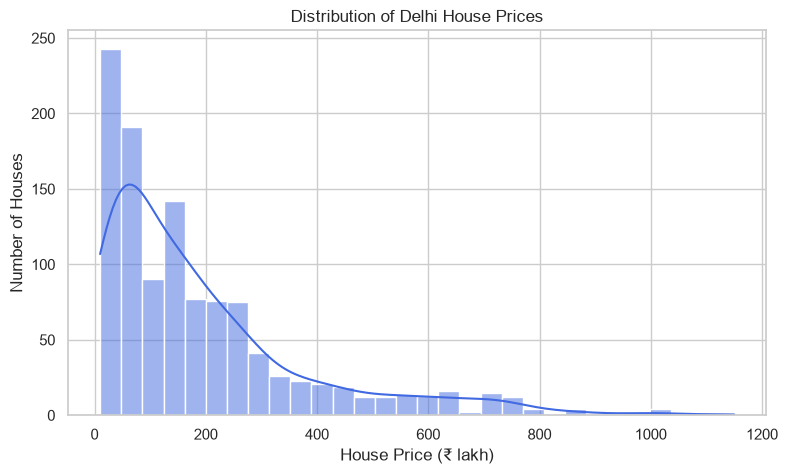

In [9]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=visual_df,
    x="Price_Lakh",
    bins=30,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of Delhi House Prices")
plt.xlabel("House Price (₹ lakh)")
plt.ylabel("Number of Houses")
plt.show()

# 5.4 Number of properties by BHK #

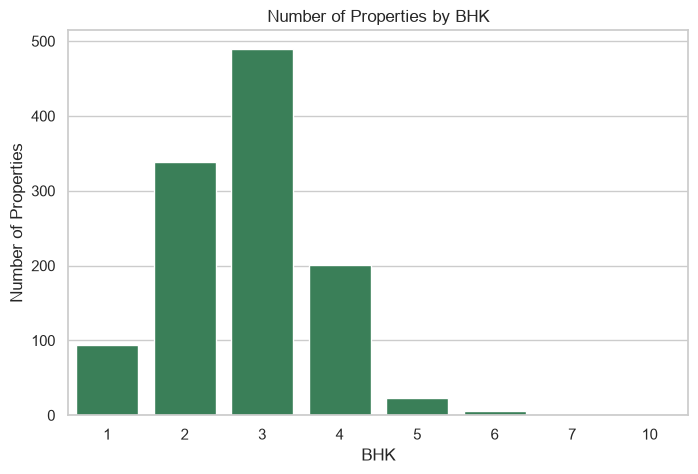

In [10]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_eda,
    x="BHK",
    color="seagreen"
)

plt.title("Number of Properties by BHK")
plt.xlabel("BHK")
plt.ylabel("Number of Properties")
plt.show()

# 5.5 Area vs House price #

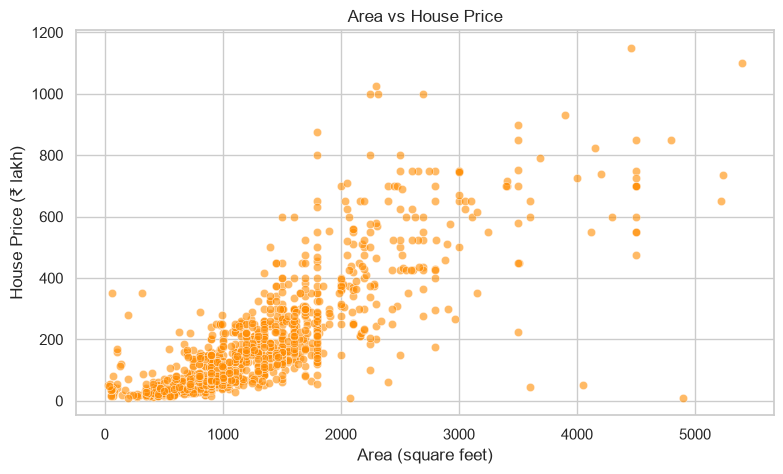

In [11]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=visual_df,
    x="Area",
    y="Price_Lakh",
    alpha=0.6,
    color="darkorange"
)

plt.title("Area vs House Price")
plt.xlabel("Area (square feet)")
plt.ylabel("House Price (₹ lakh)")
plt.show()

# 5.6 Median price by BHK #

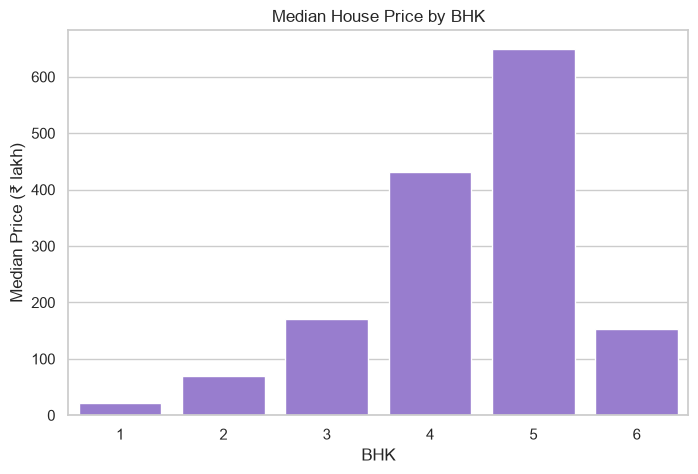

In [12]:
# Calculate median price for each BHK
bhk_summary = (
    df_eda.groupby("BHK")
    .agg(
        Median_Price=("Price_Lakh", "median"),
        Listings=("Price_Lakh", "count")
    )
    .reset_index()
)

# Use BHK categories containing at least 5 properties
bhk_summary = bhk_summary[bhk_summary["Listings"] >= 5]


plt.figure(figsize=(8, 5))

sns.barplot(
    data=bhk_summary,
    x="BHK",
    y="Median_Price",
    color="mediumpurple"
)

plt.title("Median House Price by BHK")
plt.xlabel("BHK")
plt.ylabel("Median Price (₹ lakh)")
plt.show()

# 5.7 Correlation Heatmap #

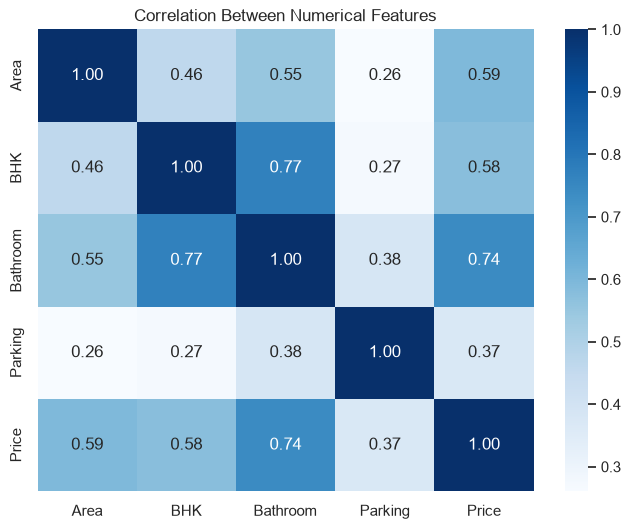

In [13]:
# Select numerical columns
numeric_columns = [
    "Area",
    "BHK",
    "Bathroom",
    "Parking",
    "Price"
]


plt.figure(figsize=(8, 6))

sns.heatmap(
    df_clean[numeric_columns].corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Features")
plt.show()

# 5.8 Top 10 expensive localities #

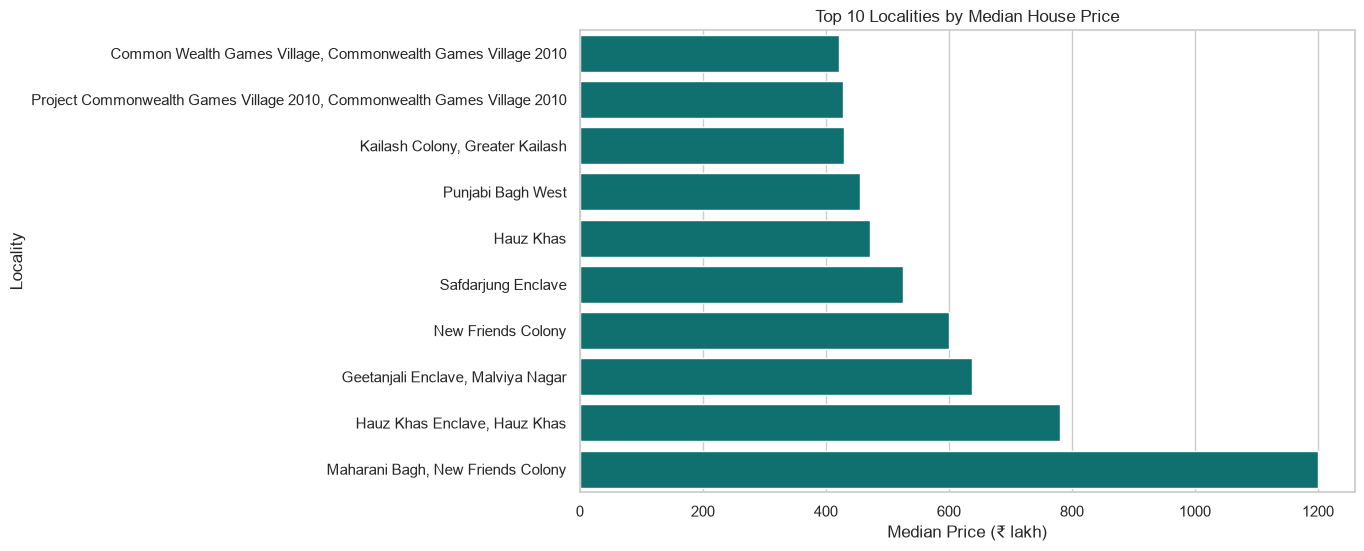

In [14]:
# Calculate median price and listing count for each locality
locality_summary = (
    df_eda[df_eda["Locality"] != "Other"]
    .groupby("Locality")
    .agg(
        Median_Price=("Price_Lakh", "median"),
        Listings=("Price_Lakh", "count")
    )
    .reset_index()
)

# Select localities containing at least 5 properties
locality_summary = locality_summary[
    locality_summary["Listings"] >= 5
]

# Select the top 10
top_localities = (
    locality_summary
    .nlargest(10, "Median_Price")
    .sort_values("Median_Price")
)


plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_localities,
    x="Median_Price",
    y="Locality",
    color="teal"
)

plt.title("Top 10 Localities by Median House Price")
plt.xlabel("Median Price (₹ lakh)")
plt.ylabel("Locality")
plt.show()

# 6. Select features and target #

In [15]:
# Columns used to predict the house price
feature_columns = [
    "Area",
    "BHK",
    "Bathroom",
    "Furnishing",
    "Locality",
    "Parking",
    "Status",
    "Transaction",
    "Type"
]


# X contains the input features
X = df_clean[feature_columns]


# y contains the value we want to predict
y = df_clean["Price"]


print("✅ Features and target selected successfully!")

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nSelected features:")
print(X.columns.tolist())

print("\nTarget column:")
print(y.name)

✅ Features and target selected successfully!
Features shape: (1154, 9)
Target shape: (1154,)

Selected features:
['Area', 'BHK', 'Bathroom', 'Furnishing', 'Locality', 'Parking', 'Status', 'Transaction', 'Type']

Target column:
Price


In [16]:
# X contains information about each property.
X.head()

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Status,Transaction,Type
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,Ready_to_move,New_Property,Builder_Floor
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,Ready_to_move,New_Property,Apartment
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,Ready_to_move,Resale,Apartment
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,Ready_to_move,Resale,Builder_Floor
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,Ready_to_move,New_Property,Builder_Floor


In [17]:
# y contains the actual house price.
y.head()

0     6500000
1     5000000
2    15500000
3     4200000
4     6200000
Name: Price, dtype: int64

# 7. Train Test Split #

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,                  # Input features
    y,                  # Target column
    test_size=0.20,     # 20% data for testing
    random_state=42     # Produces the same split every time
)


print("✅ Train-test split completed successfully!")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

✅ Train-test split completed successfully!
X_train shape: (923, 9)
X_test shape: (231, 9)
y_train shape: (923,)
y_test shape: (231,)


* X_train — features used for training
* y_train — prices used for training
* X_test — features used for testing
* y_test — actual prices used for evaluation
* random_state=42 — keeps the split consistent every time

# 8. Pipeline #

In [19]:
# Numerical columns
numerical_features = [
    "Area",
    "BHK",
    "Bathroom",
    "Parking"
]


# Categorical columns
categorical_features = [
    "Furnishing",
    "Locality",
    "Status",
    "Transaction",
    "Type"
]


# Numerical pipeline
# 1. Fill missing values using median
# 2. Standardize numerical values
numerical_pipeline = Pipeline(
    steps=[
        ("missing_values", SimpleImputer(strategy="median")),
        ("scaling", StandardScaler())
    ]
)


# Categorical pipeline
# 1. Fill missing values using most frequent value
# 2. Convert categories using one-hot encoding
categorical_pipeline = Pipeline(
    steps=[
        ("missing_values", SimpleImputer(strategy="most_frequent")),
        (
            "one_hot_encoding",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


# Combine both pipelines
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)


print("✅ Preprocessing pipeline created successfully!")

✅ Preprocessing pipeline created successfully!


* SimpleImputer handles possible missing values.
* StandardScaler puts numerical features on a similar scale.
* OneHotEncoder converts text categories into numerical columns.
* handle_unknown="ignore" prevents errors when Streamlit receives an unseen category.
* ColumnTransformer applies the correct processing to each column type.

# 9. Train Model(Regression) #

In [20]:
from sklearn.base import clone


# Regression algorithms
regression_algorithms = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}


# Dictionary for storing trained pipelines
trained_models = {}


# Train each regression model
for model_name, algorithm in regression_algorithms.items():

    # Combine preprocessing and regression algorithm
    model_pipeline = Pipeline(
        steps=[
            ("preprocessing", clone(preprocessor)),
            ("regressor", algorithm)
        ]
    )

    # Train using only the training data
    model_pipeline.fit(X_train, y_train)

    # Store the trained pipeline
    trained_models[model_name] = model_pipeline

    print(f"✅ {model_name} trained successfully!")

✅ Linear Regression trained successfully!
✅ Random Forest trained successfully!
✅ Gradient Boosting trained successfully!


In [21]:
trained_models["Linear Regression"]
trained_models["Random Forest"]
trained_models["Gradient Boosting"]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Area','BHK','Bathroom',...,'Status','Transaction','Type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of co

# 10. Evaluate and Compare Model #

In [22]:
evaluation_results = []
model_predictions = {}


for model_name, model in trained_models.items():

    # Predict house prices using testing data
    y_pred = model.predict(X_test)

    # Store predictions for later use
    model_predictions[model_name] = y_pred

    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)

    mse = mean_squared_error(y_test, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, y_pred)

    # Store the results
    evaluation_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })


# Convert results into a DataFrame
evaluation_df = pd.DataFrame(evaluation_results)


# Convert rupee errors into lakhs for easier understanding
evaluation_df["MAE (₹ Lakh)"] = (
    evaluation_df["MAE"] / 100000
)

evaluation_df["RMSE (₹ Lakh)"] = (
    evaluation_df["RMSE"] / 100000
)


# Arrange models from lowest to highest RMSE
evaluation_df = evaluation_df.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)


print("✅ Model evaluation completed!")

evaluation_df[
    [
        "Model",
        "MAE (₹ Lakh)",
        "RMSE (₹ Lakh)",
        "R2 Score"
    ]
].round(3)

✅ Model evaluation completed!


,Model,MAE (₹ Lakh),RMSE (₹ Lakh),R2 Score
0,Random Forest,45.581,76.549,0.845
1,Gradient Boosting,54.680,85.770,0.805
2,Linear Regression,66.949,98.140,0.745


# 11. Select the best model #

In [23]:
# The first model has the lowest RMSE
best_model_name = evaluation_df.loc[0, "Model"]

# Get the trained best-model pipeline
best_model = trained_models[best_model_name]


print("Best regression model:", best_model_name)

print(
    "Best R² score:",
    round(evaluation_df.loc[0, "R2 Score"], 3)
)

print(
    "Best RMSE:",
    round(evaluation_df.loc[0, "RMSE (₹ Lakh)"], 2),
    "lakh"
)

Best regression model: Random Forest
Best R² score: 0.845
Best RMSE: 76.55 lakh


# 11.1 Visual comparison #

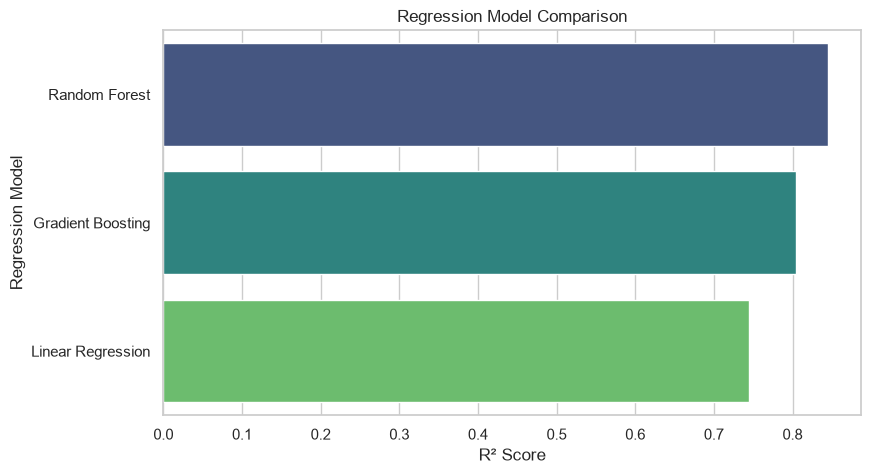

In [24]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=evaluation_df,
    x="R2 Score",
    y="Model",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.title("Regression Model Comparison")
plt.xlabel("R² Score")
plt.ylabel("Regression Model")

plt.show()

* MAE: Average prediction error. Lower is better.
* RMSE: Gives more importance to large prediction errors. Lower is better.
* R² score: Explains how well the model predicts prices. Higher and closer to 1 is better.

  The code chooses the model with the lowest RMSE as best_model.

# 12. Save the best trained model #

In [25]:
from pathlib import Path
import joblib


# Create the model folder
model_folder = Path("model")
model_folder.mkdir(exist_ok=True)


# Create the model file path
model_path = model_folder / "house_price_model.joblib"


# Save the best preprocessing and model pipeline
joblib.dump(best_model, model_path)


print("✅ Best model saved successfully!")
print("Best model:", best_model_name)
print("Saved location:", model_path)

✅ Best model saved successfully!
Best model: Random Forest
Saved location: model\house_price_model.joblib
